In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

In [2]:
df = pd.read_csv("data.csv")
df = df.drop(columns = ['date'])

In [3]:
X = df.drop('weather', axis = 1)
Y = df['weather']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)


In [4]:
ros = RandomOverSampler(random_state=42)
X_train_balanced, Y_train_balanced = ros.fit_resample(X_train, Y_train)

In [5]:
Counter(Y_train_balanced)

Counter({'rain': 449, 'sun': 449, 'fog': 449, 'drizzle': 449, 'snow': 449})

In [6]:
# Visualizing accuracy vs. number of trees
n_estimators_range = range(10, 201, 10)
cv_scores = []

In [7]:
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators = n, random_state = 42, n_jobs = -1)
    scores = cross_val_score(rf_temp, X_train_balanced, Y_train_balanced, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

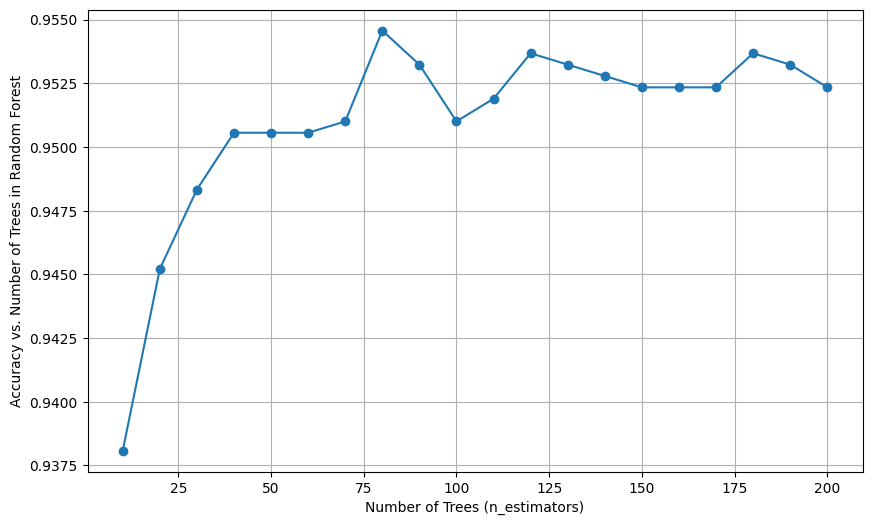

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, cv_scores, marker = 'o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy vs. Number of Trees in Random Forest")
plt.grid(True)
plt.show()

In [9]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split' : [2, 4, 6], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

rf = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train_balanced, Y_train_balanced)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [10]:
best_model = grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_) 

Best Hyperparameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 100}


In [11]:
y_pred = best_model.predict(X_test)

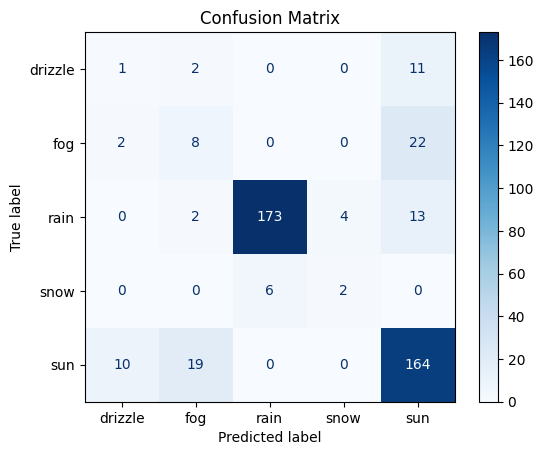

In [12]:
cm = confusion_matrix(Y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [13]:
report = classification_report(Y_test, y_pred, labels = best_model.classes_)
print("Classification Report: ")
print(report)

Classification Report: 
              precision    recall  f1-score   support

     drizzle       0.08      0.07      0.07        14
         fog       0.26      0.25      0.25        32
        rain       0.97      0.90      0.93       192
        snow       0.33      0.25      0.29         8
         sun       0.78      0.85      0.81       193

    accuracy                           0.79       439
   macro avg       0.48      0.46      0.47       439
weighted avg       0.79      0.79      0.79       439



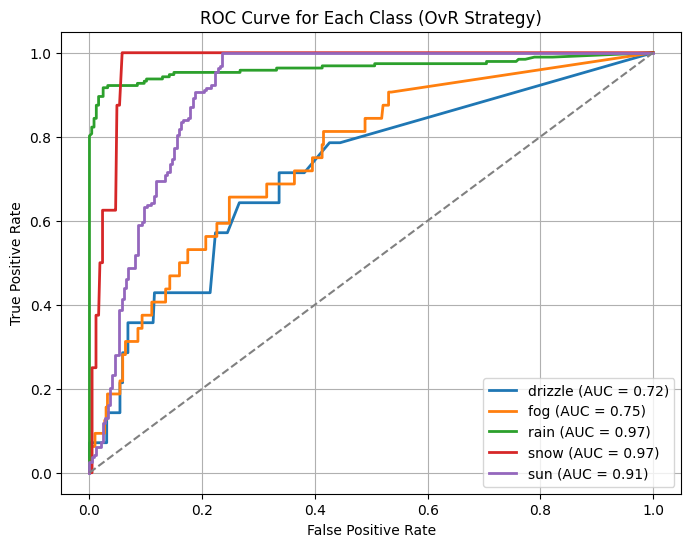

In [15]:
y_test_binarized = label_binarize(Y_test, classes = best_model.classes_)
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:,i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label],tpr[class_label], lw =2, 
             label = f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0,1], [0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()